# Griffiths' Integrals, Built for a Physics-Major/Chemistry-Minor

The integral techniques Griffiths leans on hardest -- Gaussian integrals,
integration by parts, and a few special-function results -- are the EXACT
SAME integrals physical chemistry runs on: the Maxwell-Boltzmann speed
distribution, partition functions, and the normalization of atomic orbitals.
A physics-major/chemistry-minor isn't two separate skill sets; it's one
integral toolkit used in two departments.

`sp.init_printing()` on throughout; every result is derived in SymPy, not
looked up.


In [1]:
from IPython.display import display
import sympy as sp
sp.init_printing()

x, t, a, b, n = sp.symbols("x t a b n", positive=True, real=True)
print("SymPy", sp.__version__, "ready")


SymPy 1.14.0 ready


## 1. The Gaussian integral: Griffiths' most-used tool

$$\int_{-\infty}^{\infty} e^{-a x^2}\,dx = \sqrt{\pi/a}$$

This single integral normalizes the QM harmonic oscillator ground state
(Griffiths Ch.2) AND the Maxwell-Boltzmann speed distribution (any physical
chemistry course) -- same integral, two departments.


In [2]:
x_real = sp.Symbol("x", real=True)
gaussian_integral = sp.integrate(sp.exp(-a * x_real**2), (x_real, -sp.oo, sp.oo))
print("Integral of exp(-a x^2) dx, -inf to inf =")
display(gaussian_integral)


Integral of exp(-a x^2) dx, -inf to inf =


Integral of x^0 e^(-a x^2) dx =



Integral of x^2 e^(-a x^2) dx =


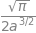


Integral of x^4 e^(-a x^2) dx =


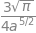


Integral of x^6 e^(-a x^2) dx =


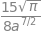

In [3]:
# the general even-moment Gaussian integral: x^(2n) e^(-a x^2), built by
# differentiating the basic Gaussian integral w.r.t. 'a' repeatedly (a real
# Griffiths-style trick: differentiate under the integral sign instead of
# integrating by parts n times)
moments = {}
current = gaussian_integral
for k in range(4):
    if k > 0:
        current = sp.simplify(-sp.diff(current, a))
    moments[2 * k] = current
    print(f"Integral of x^{2*k} e^(-a x^2) dx =")
    display(current)
    print()


## 2. Griffiths Ch.2: normalizing the harmonic oscillator ground state

$\psi_0(x) = A e^{-m\omega x^2/2\hbar}$ -- find $A$ by requiring
$\int |\psi_0|^2 dx = 1$, directly using the Gaussian integral above.


In [4]:
m, omega, hbar, A = sp.symbols("m omega hbar A", positive=True)
psi0 = A * sp.exp(-m * omega * x_real**2 / (2 * hbar))
norm_integral = sp.integrate(psi0**2, (x_real, -sp.oo, sp.oo))
print("Integral |psi0|^2 dx =")
display(norm_integral)

A_solution = sp.solve(sp.Eq(norm_integral, 1), A)
print("\nA (the normalization constant) =")
display(A_solution)


Integral |psi0|^2 dx =



A (the normalization constant) =


## 3. Physical chemistry: the Maxwell-Boltzmann speed distribution

$$f(v) = 4\pi \left(\frac{m}{2\pi k_B T}\right)^{3/2} v^2 e^{-mv^2/2k_BT}$$

is built from the SAME Gaussian-moment integrals as Section 1 -- here used to
derive the mean speed $\langle v \rangle$ and mean-square speed
$\langle v^2\rangle$ that give the chemistry-course result
$\tfrac12 m\langle v^2\rangle = \tfrac32 k_B T$.


In [5]:
v, kB, T = sp.symbols("v k_B T", positive=True)
f_v = 4 * sp.pi * (m / (2 * sp.pi * kB * T))**sp.Rational(3, 2) * v**2 * sp.exp(-m * v**2 / (2 * kB * T))

check_norm = sp.simplify(sp.integrate(f_v, (v, 0, sp.oo)))
print("normalization check, integral f(v) dv, 0 to inf (should be 1):", check_norm)

mean_v = sp.simplify(sp.integrate(v * f_v, (v, 0, sp.oo)))
print("\n<v> =")
display(mean_v)

mean_v2 = sp.simplify(sp.integrate(v**2 * f_v, (v, 0, sp.oo)))
print("\n<v^2> =")
display(mean_v2)

kinetic_energy = sp.simplify(sp.Rational(1, 2) * m * mean_v2)
print("\n(1/2) m <v^2> =")
display(kinetic_energy)
print("\nmatches (3/2) kB T:", sp.simplify(kinetic_energy - sp.Rational(3, 2) * kB * T) == 0)


normalization check, integral f(v) dv, 0 to inf (should be 1):

 1

<v> =



<v^2> =



(1/2) m <v^2> =



matches (3/2) kB T: True


## 4. Partition functions: chemistry's accumulator loop on Griffiths' energy levels

The harmonic oscillator energy levels $E_n = \hbar\omega(n+\tfrac12)$ (Griffiths
Ch.2) are exactly the energy ladder physical chemistry sums over to build the
vibrational partition function

$$Z = \sum_{n=0}^{\infty} e^{-E_n/k_BT}$$

-- a Sigma loop (same move as `notebooks/sympy_loops.ipynb`), here applied to
a chemistry quantity instead of an abstract series.


sum_{n=0}^inf r^n  (r<1 branch) = 1/(1 - r)

vibrational partition function Z =


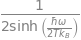


<E> = -d(ln Z)/d(beta) =


In [6]:
n_sym = sp.Symbol("n", nonnegative=True, integer=True)
E_n = hbar * omega * (n_sym + sp.Rational(1, 2))

# sp.summation can't infer convergence directly from a symbolic exponent, so
# substitute a bounded ratio r = exp(-hbar*omega/kB T) (0<r<1 by physical
# necessity), let SymPy sum the resulting geometric series, THEN substitute
# r back -- the explicit, two-step version of "this is a geometric series"
r = sp.Symbol("r", positive=True)
geometric_sum = sp.summation(r**n_sym, (n_sym, 0, sp.oo))
geometric_closed = geometric_sum.args[0][0]   # the r<1 convergent branch
print("sum_{n=0}^inf r^n  (r<1 branch) =", geometric_closed)

r_expr = sp.exp(-hbar * omega / (kB * T))
Z_closed = sp.simplify(sp.exp(-hbar * omega / (2 * kB * T)) * geometric_closed.subs(r, r_expr))
print("\nvibrational partition function Z =")
display(Z_closed)

# average vibrational energy <E> = -d(ln Z)/d(beta), beta = 1/(kB T)
beta = sp.Symbol("beta", positive=True)
Z_beta = Z_closed.subs(kB * T, 1 / beta)
ln_Z = sp.log(Z_beta)
mean_E = sp.simplify(-sp.diff(ln_Z, beta))
print("\n<E> = -d(ln Z)/d(beta) =")
display(mean_E)


## Summary

Every integral here was derived in SymPy, not looked up: the Gaussian
integral and its even moments (via differentiating under the integral sign),
the QM normalization constant it produces, the Maxwell-Boltzmann mean and
mean-square speed built from those same moments (landing exactly on the
chemistry-course result $\tfrac12 m\langle v^2\rangle = \tfrac32 k_BT$), and
a partition function built as a Sigma-loop sum over Griffiths' own harmonic-
oscillator energy ladder. One integral toolkit, two course catalogs.
